# PaceVision — Matematyka Obliczania Katow Stawowych

Ten notebook wyjasnia matematyke stojaca za obliczeniami katow stawowych w systemie PaceVision.
Omawia uklady wspolrzednych, geometrie wektorowa, 5 mierzonych katow,
wygladzanie filtrem Savitzky'ego-Golaya oraz punktacje progowa.

**Wymagane biblioteki:** `numpy`, `matplotlib`, `scipy`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.signal import savgol_filter

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
print("Biblioteki zaladowane.")

## 1. Uklad wspolrzednych MediaPipe

MediaPipe Pose dostarcza dwa zestawy punktow orientacyjnych (landmarks) dla kazdej klatki:

| Wlasciwosc | `pose_landmarks` (znormalizowane) | `pose_world_landmarks` (swiatowe) |
|---|---|---|
| **x, y** | [0, 1] wzgledem rozmiaru klatki | Metry (skala rzeczywista) |
| **z** | Glebia wzgledem bioder (niemetryczna) | Metry (skala rzeczywista) |
| **Poczatek ukladu** | Lewy gorny rog klatki | Punkt srodkowy miedzy biodrami |
| **Zastosowanie** | Rysowanie nakladek na wideo | **Obliczenia katow** |

**PaceVision uzywa World Landmarks** do wszystkich obliczen katowych, poniewaz
dostarczaja metryczne wspolrzedne 3D niezalezne od odleglosci kamery i rozdzielczosci.

### Orientacja osi (World Landmarks)
```
        +Y (w dol)
         |
         |
         +-------> +X (w prawo)
        /
       /
      +Z (od kamery)
```

Poczatek ukladu wspolrzednych znajduje sie w punkcie srodkowym miedzy lewym a prawym biodrem.

In [ ]:
# Wizualizacja ukladu wspolrzednych z modelem szkieletowym

fig, ax = plt.subplots(1, 1, figsize=(8, 10))

# Symulowane pozycje swiatowych landmarkow (w metrach) dla stojacej osoby (widok z boku)
cialo = {
    "glowa":    (0.00, -0.60),
    "bark":     (0.00, -0.40),
    "lokiec":   (0.02, -0.20),
    "nadg.":    (0.05, -0.05),
    "biodro":   (0.00,  0.00),   # poczatek ukladu
    "kolano":   (0.02,  0.35),
    "kostka":   (0.00,  0.70),
    "stopa":    (0.08,  0.72),
    "pieta":    (-0.03, 0.71),
}

# Rysowanie szkieletu
polaczenia = [
    ("glowa", "bark"), ("bark", "lokiec"), ("lokiec", "nadg."),
    ("bark", "biodro"), ("biodro", "kolano"), ("kolano", "kostka"),
    ("kostka", "stopa"), ("kostka", "pieta"),
]
for a, b in polaczenia:
    ax.plot([cialo[a][0], cialo[b][0]], [cialo[a][1], cialo[b][1]], "o-", 
            color="#00C853", linewidth=2.5, markersize=8, zorder=3)

# Etykiety stawow
for nazwa, (x, y) in cialo.items():
    ax.annotate(nazwa, (x, y), textcoords="offset points",
                xytext=(12, 4), fontsize=9, color="#333")

# Rysowanie osi w poczatku ukladu (biodro)
ax.annotate("", xy=(0.25, 0), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="red", lw=2))
ax.text(0.26, 0.02, "+X (w prawo)", color="red", fontsize=10)

ax.annotate("", xy=(0, 0.25), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color="blue", lw=2))
ax.text(0.02, 0.26, "+Y (w dol)", color="blue", fontsize=10)

ax.set_xlim(-0.3, 0.5)
ax.set_ylim(0.85, -0.75)  # odwrocone, zeby +Y wskazywal w dol wizualnie
ax.set_aspect("equal")
ax.set_xlabel("X (metry)")
ax.set_ylabel("Y (metry)")
ax.set_title("MediaPipe World Landmarks — Widok z boku (plaszczyzna strzalkowa)")
plt.tight_layout()
plt.show()

## 2. Matematyka wektorowa — Kat miedzy trzema punktami

Majac trzy punkty **A**, **B**, **C**, kat w wierzcholku **B** obliczamy za pomoca iloczynu skalarnego:

$$\vec{BA} = A - B, \quad \vec{BC} = C - B$$

$$\cos(\theta) = \frac{\vec{BA} \cdot \vec{BC}}{|\vec{BA}| \cdot |\vec{BC}|}$$

$$\theta = \arccos\left(\text{clamp}\left(\cos(\theta),\; -1,\; 1\right)\right)$$

Funkcja `clamp` zabezpiecza przed bledem zmiennoprzecinkowym, ktory moglby
spowodowac, ze `cos(theta)` wyjdzie poza przedzial [-1, 1], a `arccos` zwroci `NaN`.

### Dlaczego iloczyn skalarny?

Iloczyn skalarny dwoch wektorow daje `|a| * |b| * cos(kat)`. Dziedzac
przez dlugosci wektorow, izolujemy cosinus kata miedzy nimi. Ta metoda
dziala identycznie w 2D i 3D — wystarczy zmienic wymiarowosc wektorow.

In [ ]:
def angle_3d(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    """Kat w stopniach w wierzcholku b, dla punktow 3D a, b, c."""
    ba = a - b
    bc = c - b
    cos_theta = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-10)
    return float(np.degrees(np.arccos(np.clip(cos_theta, -1.0, 1.0))))


def angle_2d(a: np.ndarray, b: np.ndarray, c: np.ndarray) -> float:
    """Kat w stopniach w wierzcholku b, uzywajac tylko skladowych x, y."""
    return angle_3d(a[:2], b[:2], c[:2])


# ── Przyklady obliczen ───────────────────────────────────────────────
# Kat prosty: punkty wzdluz osi X i Y
A = np.array([1, 0, 0])
B = np.array([0, 0, 0])  # wierzcholek
C = np.array([0, 1, 0])
print(f"Test kata prostego:    {angle_3d(A, B, C):.1f}°  (oczekiwane 90°)")

# Linia prosta (kat pelny)
A2 = np.array([1, 0, 0])
B2 = np.array([0, 0, 0])
C2 = np.array([-1, 0, 0])
print(f"Test linii prostej:   {angle_3d(A2, B2, C2):.1f}° (oczekiwane 180°)")

# Kat 60 stopni
A3 = np.array([1, 0, 0])
B3 = np.array([0, 0, 0])
C3 = np.array([0.5, np.sqrt(3)/2, 0])
print(f"Test 60 stopni:       {angle_3d(A3, B3, C3):.1f}°  (oczekiwane 60°)")

## 3. Obliczanie kata w 2D vs 3D

Przy **kamerze z boku** (plaszczyzna strzalkowa) biegacz porusza sie glownie w plaszczyznie X-Y.
Os Z (glebia) jest prostopadla do kamery. W tej konfiguracji:

- **Katy 2D** (tylko X, Y) sa bardzo zblizzone do **katow 3D**, poniewaz skladowa Z jest mala wzgledem X i Y.
- Skladowa Z zaczyna miec znaczenie dopiero gdy biegacz jest **obrocony** wzgledem kamery (np. skreca tulowiem).

Przy wymaganiu widoku z boku w PaceVision, 3D jest nieco dokladniejsze (uwzglednia drobne obroty ciala),
ale 2D stanowi poprawne przyblizenie.

In [ ]:
# Porownanie katow 2D vs 3D przy rosnacym obrocie ciala

rotations = np.linspace(0, 45, 50)  # stopnie obrotu ciala wokol osi Y
katy_3d = []
katy_2d = []

# Zgiecie kolana: biodro(0, 0, 0) -> kolano(0.05, 0.40, z) -> kostka(0, 0.75, z)
# Wraz z obrotem ciala rosna skladowe Z
for rot_deg in rotations:
    rot_rad = np.radians(rot_deg)
    z_offset = np.sin(rot_rad) * 0.1  # przesuniecie glebokosci z obrotu
    
    biodro = np.array([0.00, 0.00, 0.00])
    kolano = np.array([0.05, 0.40, z_offset])
    kostka = np.array([0.00, 0.75, z_offset * 1.5])
    
    katy_3d.append(angle_3d(biodro, kolano, kostka))
    katy_2d.append(angle_2d(biodro, kolano, kostka))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(rotations, katy_3d, label="Kat 3D", linewidth=2)
ax1.plot(rotations, katy_2d, label="Kat 2D (tylko X,Y)", linewidth=2, linestyle="--")
ax1.set_xlabel("Obrot ciala (stopnie)")
ax1.set_ylabel("Kat zgiecia kolana (stopnie)")
ax1.set_title("2D vs 3D: Zgiecie kolana przy obrocie ciala")
ax1.legend()

# Rozbieznosc
rozbieznosc = np.abs(np.array(katy_3d) - np.array(katy_2d))
ax2.plot(rotations, rozbieznosc, color="red", linewidth=2)
ax2.set_xlabel("Obrot ciala (stopnie)")
ax2.set_ylabel("|3D - 2D| (stopnie)")
ax2.set_title("Rozbieznosc miedzy 2D a 3D")
ax2.axhline(y=2, color="orange", linestyle=":", label="Prog 2°")
ax2.legend()

plt.tight_layout()
plt.show()
print(f"Przy obrocie 0°:   rozbieznosc = {rozbieznosc[0]:.2f}°")
print(f"Przy obrocie 15°:  rozbieznosc = {rozbieznosc[16]:.2f}°")
print(f"Przy obrocie 45°:  rozbieznosc = {rozbieznosc[-1]:.2f}°")

## 4. Piec katow mierzonych przez PaceVision

Kazdy kat jest mierzony w **wierzcholku** (srodkowy punkt w trojce landmarkow).

| Kat | Trojka (a -> **b** -> c) | Indeksy landmarkow (lewa strona) | Moment pomiaru |
|-----|------------------------|----------------------------------|----------------|
| **Zgiecie kolana** | biodro -> **kolano** -> kostka | 23 -> **25** -> 27 | Klatka kontaktu z podlozem |
| **Zgiecie biodra** | bark -> **biodro** -> kolano | 11 -> **23** -> 25 | Maksimum w czasie kroku |
| **Pochylenie tulowia** | ucho -> **bark** -> biodro | 7 -> **11** -> 23 | Srednia w czasie kroku |
| **Dorsyfleksja kostki** | kolano -> **kostka** -> palec_stopy | 25 -> **27** -> 31 | Faza podparcia |
| **Wymach ramion** | bark -> **lokiec** -> nadgarstek | 11 -> **13** -> 15 | Zakres ruchu |

In [ ]:
# Symulowane pozycje swiatowych landmarkow (metry) dla biegacza w fazie kontaktu z podlozem
# Landmarki lewej strony ciala, przyblizenie uchwytu w polowie kroku

landmarks = {
    7:  np.array([ 0.01, -0.62, 0.00]),  # lewe ucho
    11: np.array([ 0.00, -0.40, 0.00]),  # lewy bark
    13: np.array([-0.08, -0.22, 0.00]),  # lewy lokiec
    15: np.array([-0.05, -0.05, 0.00]),  # lewy nadgarstek
    23: np.array([ 0.00,  0.00, 0.00]),  # lewe biodro (poczatek ukladu)
    25: np.array([ 0.08,  0.38, 0.00]),  # lewe kolano
    27: np.array([ 0.02,  0.72, 0.00]),  # lewa kostka
    31: np.array([ 0.12,  0.73, 0.00]),  # lewy palec stopy
}

# Obliczenie wszystkich 5 katow
definicje_katow = {
    "Zgiecie kolana":       (23, 25, 27),
    "Zgiecie biodra":       (11, 23, 25),
    "Pochylenie tulowia":   ( 7, 11, 23),
    "Dorsyfleksja kostki":  (25, 27, 31),
    "Wymach ramion":        (11, 13, 15),
}

progi = {
    "Zgiecie kolana":       (25, 45),
    "Zgiecie biodra":       (60, 70),
    "Pochylenie tulowia":   ( 5, 12),
    "Dorsyfleksja kostki":  (18, 25),
    "Wymach ramion":        (0, 180),  # brak progu dla zakresu ruchu ramion
}

print("OBLICZENIA KATOW")
print("=" * 65)
for nazwa, (a, b, c) in definicje_katow.items():
    deg = angle_3d(landmarks[a], landmarks[b], landmarks[c])
    lo, hi = progi[nazwa]
    status = "OPTYMALNY" if lo <= deg <= hi else "OSTRZEZENIE" if abs(deg - lo) < 10 or abs(deg - hi) < 10 else "ZLY"
    print(f"  {nazwa:25s}  {deg:6.1f}°   zakres [{lo}-{hi}°]  -> {status}")

In [ ]:
# Wizualizacja kazdego kata na modelu szkieletowym

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
kolory = ["#FF6D00", "#2979FF", "#00C853", "#AA00FF", "#FF1744"]

for ax, (nazwa, (a_idx, b_idx, c_idx)), kolor in zip(axes, definicje_katow.items(), kolory):
    a_pt, b_pt, c_pt = landmarks[a_idx], landmarks[b_idx], landmarks[c_idx]
    deg = angle_3d(a_pt, b_pt, c_pt)
    
    # Rysowanie calego szkieletu (przyciemniony)
    szkielet = [(7,11), (11,23), (23,25), (25,27), (27,31), (11,13), (13,15)]
    for i, j in szkielet:
        ax.plot([landmarks[i][0], landmarks[j][0]], 
                [landmarks[i][1], landmarks[j][1]], 
                "o-", color="#DDD", linewidth=1.5, markersize=4, zorder=1)
    
    # Podswietlenie mierzonej trojki
    for p1, p2 in [(a_pt, b_pt), (b_pt, c_pt)]:
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], "o-",
                color=kolor, linewidth=3, markersize=8, zorder=3)
    
    # Oznaczenie wierzcholka
    ax.plot(b_pt[0], b_pt[1], "o", color=kolor, markersize=12, zorder=4)
    
    ax.set_title(f"{nazwa}\n{deg:.1f}°", fontsize=10, fontweight="bold")
    ax.set_xlim(-0.2, 0.25)
    ax.set_ylim(0.85, -0.75)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("5 katow PaceVision — podswietlone trojki landmarkow", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Wygladzanie filtrem Savitzky'ego-Golaya

Landmarki MediaPipe drza miedzy klatkami, szczegolnie kostka. PaceVision stosuje
**filtr Savitzky'ego-Golaya** (`okno=7, stopien wielomianu=2`) do wygladzania wspolrzednych
przed obliczeniem katow.

### Jak to dziala
- Dopasowuje wielomian 2. stopnia do ostatnich 7 punktow danych
- Oblicza wartosc wielomianu w najnowszym punkcie
- Lepiej zachowuje szczyty i doliny niz zwykla srednia kroczaca
- Implementacja w `scipy.signal.savgol_filter`

In [ ]:
# Symulacja zaszumionej wspolrzednej Y kostki przez 60 klatek (~2 sekundy przy 30fps)

np.random.seed(42)
n_klatek = 60
t = np.arange(n_klatek)

# Prawdziwy sygnal: gladki ruch sinusoidalny (chod biegowy)
prawdziwe_y = 0.70 + 0.03 * np.sin(2 * np.pi * t / 15)  # czestotliwosc kroku ~2 Hz

# Zaszumiony sygnal: drgania MediaPipe (kostka jest szczegolnie zaszumiona)
szum = np.random.normal(0, 0.012, n_klatek)
zaszumione_y = prawdziwe_y + szum

# Wygladzone filtrem Savitzky'ego-Golaya
sg_y = savgol_filter(zaszumione_y, window_length=7, polyorder=2)

# Srednia kroczaca do porownania
kernel = np.ones(7) / 7
sma_y = np.convolve(zaszumione_y, kernel, mode="same")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Gora: wszystkie sygnaly
ax1.plot(t, prawdziwe_y, "k--", linewidth=1.5, label="Prawdziwy sygnal", alpha=0.5)
ax1.plot(t, zaszumione_y, ".", color="#CCC", markersize=4, label="Surowy (zaszumiony)")
ax1.plot(t, sg_y, linewidth=2, color="#2979FF", label="Savitzky-Golay (o=7, w=2)")
ax1.plot(t, sma_y, linewidth=2, color="#FF6D00", linestyle="--", label="Srednia kroczaca (o=7)")
ax1.set_ylabel("Kostka Y (metry)")
ax1.set_title("Wygladzanie landmarka kostki — Savitzky-Golay vs srednia kroczaca")
ax1.legend()

# Dol: blad wzgledem prawdziwego sygnalu
ax2.plot(t, np.abs(zaszumione_y - prawdziwe_y), ".", color="#CCC", markersize=3, label="Blad surowy")
ax2.plot(t, np.abs(sg_y - prawdziwe_y), linewidth=2, color="#2979FF", label="Blad SG")
ax2.plot(t, np.abs(sma_y - prawdziwe_y), linewidth=2, color="#FF6D00", linestyle="--", label="Blad SK")
ax2.set_xlabel("Klatka")
ax2.set_ylabel("|Blad| (metry)")
ax2.set_title("Blad bezwzgledny wzgledem prawdziwego sygnalu")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"RMS surowego szumu:    {np.sqrt(np.mean(szum**2)):.4f} m")
print(f"RMS residuum SG:       {np.sqrt(np.mean((sg_y - prawdziwe_y)**2)):.4f} m")
print(f"RMS residuum sr. kr.:  {np.sqrt(np.mean((sma_y - prawdziwe_y)**2)):.4f} m")

## 6. Szum kostki i zastepowanie pieta

Landmark kostki (indeks 27/28) jest najbardziej zaszumionym landmarkiem w MediaPipe Pose.
Gdy jego widocznosc (visibility) spada ponizej `0.5`, PaceVision zastepuje go landmarkiem
**piety** (indeks 29/30), ktory jest bardziej stabilny.

Wplywa to na kat **dorsyfleksji kostki** (kolano -> kostka -> palec_stopy).

In [ ]:
# Symulacja spadkow widocznosci kostki i efektu zastepowania pieta

np.random.seed(123)
n_klatek = 90

# Symulowana widocznosc kostki i piety w czasie
wid_kostki = np.clip(0.6 + 0.3 * np.sin(2 * np.pi * np.arange(n_klatek) / 30) 
                     + np.random.normal(0, 0.15, n_klatek), 0, 1)
wid_piety = np.clip(0.75 + np.random.normal(0, 0.08, n_klatek), 0, 1)

# Kat dorsyfleksji kostki: kolano -> kostka/pieta -> stopa
kolano = np.array([0.08, 0.38, 0.0])
kostka_baza = np.array([0.02, 0.72, 0.0])
pieta_baza = np.array([-0.03, 0.71, 0.0])
stopa = np.array([0.12, 0.73, 0.0])

# Obliczenie kata uzywajac kostki vs piety, w zaleznosci od widocznosci
katy_kostka = []
katy_pieta = []
katy_zastepowane = []
uzyta_pieta = []

for i in range(n_klatek):
    drganie = np.random.normal(0, 0.008, 3)
    poz_kostki = kostka_baza + drganie
    poz_piety = pieta_baza + drganie * 0.4  # pieta jest mniej zaszumiona
    
    k_kostka = angle_3d(kolano, poz_kostki, stopa)
    k_pieta = angle_3d(kolano, poz_piety, stopa)
    katy_kostka.append(k_kostka)
    katy_pieta.append(k_pieta)
    
    # Logika zastepowania
    if wid_kostki[i] >= 0.5:
        katy_zastepowane.append(k_kostka)
        uzyta_pieta.append(False)
    else:
        katy_zastepowane.append(k_pieta)
        uzyta_pieta.append(True)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Wykres widocznosci
ax1.plot(wid_kostki, label="Widocznosc kostki", color="#2979FF", linewidth=1.5)
ax1.plot(wid_piety, label="Widocznosc piety", color="#00C853", linewidth=1.5)
ax1.axhline(y=0.5, color="red", linestyle=":", linewidth=1, label="Prog (0.5)")
ax1.fill_between(range(n_klatek), 0, 1, where=[v < 0.5 for v in wid_kostki],
                 alpha=0.15, color="red", label="Zastapienie pieta")
ax1.set_ylabel("Widocznosc")
ax1.set_title("Widocznosc kostki vs piety w czasie")
ax1.legend(loc="lower right")

# Porownanie katow
ax2.plot(katy_kostka, color="#2979FF", alpha=0.4, linewidth=1, label="Zawsze kostka")
ax2.plot(katy_pieta, color="#00C853", alpha=0.4, linewidth=1, label="Zawsze pieta")
ax2.plot(katy_zastepowane, color="#FF6D00", linewidth=2, label="Strategia zastepowania")
ax2.set_xlabel("Klatka")
ax2.set_ylabel("Dorsyfleksja kostki (stopnie)")
ax2.set_title("Kat dorsyfleksji — kostka vs pieta vs strategia zastepowania")
ax2.legend()

plt.tight_layout()
plt.show()

procent_piety = sum(uzyta_pieta) / len(uzyta_pieta) * 100
print(f"Pieta uzyta w {procent_piety:.0f}% klatek")

## 7. Punktacja progowa

Kazdy kat ma **optymalny zakres** wynikajacy z badan biomechaniki efektywnego biegu.
Wartosci sa oceniane jako:

| Ocena | Znaczenie |
|-------|-----------|
| **Optymalny** | W optymalnym zakresie |
| **Ostrzezenie** | W granicach 10° od granicy zakresu |
| **Zly** | Ponad 10° poza zakresem |

### Progi

| Metryka | Optymalny zakres |
|---------|:----------------:|
| Zgiecie kolana (przy kontakcie) | 25-45° |
| Zgiecie biodra (maks.) | 60-70° |
| Pochylenie tulowia (srednie) | 5-12° |
| Dorsyfleksja kostki (faza podparcia) | 18-25° |
| Kadencja | 170-185 krokow/min |

In [ ]:
# Wizualizacja stref progowych dla kazdego kata

progi_wiz = {
    "Zgiecie kolana\n(przy kontakcie)":     (25, 45),
    "Zgiecie biodra\n(maks.)":              (60, 70),
    "Pochylenie tulowia\n(srednie)":        (5, 12),
    "Dorsyfleksja kostki\n(faza podparcia)":(18, 25),
}

MARGINES_OSTRZEZENIA = 10  # stopnie

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (nazwa, (lo, hi)) in zip(axes, progi_wiz.items()):
    pelny_zakres = max(hi + 25, 90)
    
    # Strefy "zly"
    ax.barh(0, lo - MARGINES_OSTRZEZENIA, left=0, height=0.6, color="#FF1744", alpha=0.3)
    ax.barh(0, pelny_zakres - (hi + MARGINES_OSTRZEZENIA), left=hi + MARGINES_OSTRZEZENIA, 
            height=0.6, color="#FF1744", alpha=0.3)
    
    # Strefy "ostrzezenie"
    ax.barh(0, MARGINES_OSTRZEZENIA, left=lo - MARGINES_OSTRZEZENIA, height=0.6, color="#FFD600", alpha=0.4)
    ax.barh(0, MARGINES_OSTRZEZENIA, left=hi, height=0.6, color="#FFD600", alpha=0.4)
    
    # Strefa "optymalny"
    ax.barh(0, hi - lo, left=lo, height=0.6, color="#00C853", alpha=0.5)
    
    ax.set_xlim(0, pelny_zakres)
    ax.set_ylim(-0.5, 0.5)
    ax.set_yticks([])
    ax.set_xlabel("Stopnie")
    ax.set_title(nazwa, fontsize=10, fontweight="bold")
    
    # Etykiety
    srodek = (lo + hi) / 2
    ax.text(srodek, 0, f"{lo}-{hi}°", ha="center", va="center", fontsize=9, fontweight="bold")

# Legenda
from matplotlib.patches import Patch
elementy_legendy = [
    Patch(facecolor="#00C853", alpha=0.5, label="Optymalny"),
    Patch(facecolor="#FFD600", alpha=0.4, label="Ostrzezenie (w granicach 10°)"),
    Patch(facecolor="#FF1744", alpha=0.3, label="Zly"),
]
fig.legend(handles=elementy_legendy, loc="lower center", ncol=3, fontsize=10, 
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle("Strefy progow biomechanicznych", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Full Pipeline Demo

Putting it all together: load sample landmark data, smooth it, compute all 5 angles, and score each one.

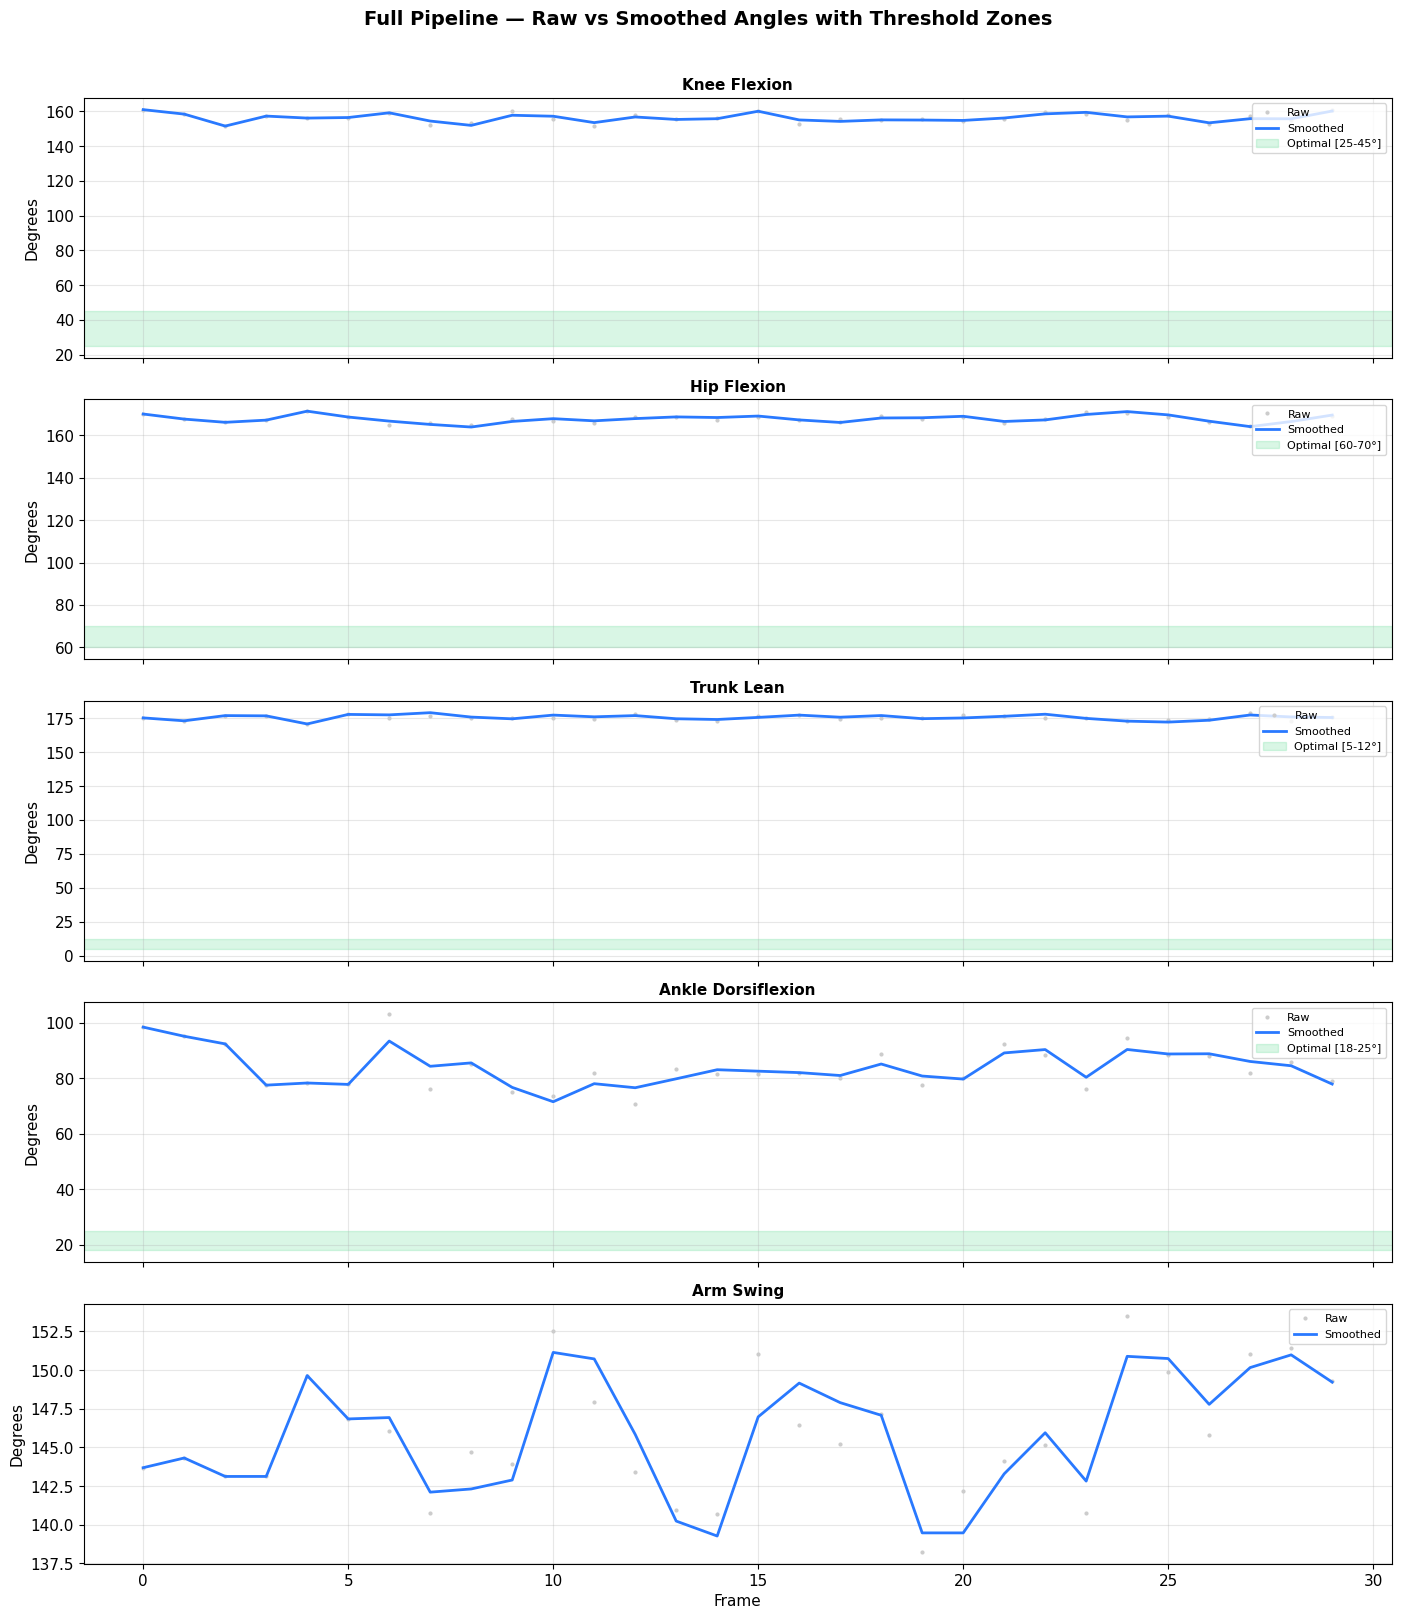


FINAL FRAME SCORES (frame 30)
  Knee Flexion                160.2°  [ 25- 45°]  POOR
  Hip Flexion                 169.5°  [ 60- 70°]  POOR
  Trunk Lean                  175.5°  [  5- 12°]  POOR
  Ankle Dorsiflexion           77.9°  [ 18- 25°]  POOR
  Arm Swing                   149.2°  [  0-180°]  OPTIMAL


In [20]:
# Full pipeline: generate 30 frames of simulated data → smooth → compute angles → score

np.random.seed(7)
n_frames = 30
WINDOW = 7
POLY = 2

# Simulated landmark positions with per-frame jitter
base_landmarks = {
    7:  np.array([ 0.01, -0.62, 0.00]),  # ear
    11: np.array([ 0.00, -0.40, 0.00]),  # shoulder
    13: np.array([-0.08, -0.22, 0.00]),  # elbow
    15: np.array([-0.05, -0.05, 0.00]),  # wrist
    23: np.array([ 0.00,  0.00, 0.00]),  # hip
    25: np.array([ 0.08,  0.38, 0.00]),  # knee
    27: np.array([ 0.02,  0.72, 0.00]),  # ankle
    31: np.array([ 0.12,  0.73, 0.00]),  # foot
}

angle_names = ["Knee Flexion", "Hip Flexion", "Trunk Lean", "Ankle Dorsiflexion", "Arm Swing"]
angle_triplets = [(23,25,27), (11,23,25), (7,11,23), (25,27,31), (11,13,15)]
angle_thresholds = [(25,45), (60,70), (5,12), (18,25), (0,180)]

# Accumulate raw and smoothed angle time-series
raw_angles = {name: [] for name in angle_names}
smooth_angles = {name: [] for name in angle_names}

# Buffers for SG smoothing (per landmark, per axis)
buffers = {idx: [[], [], []] for idx in base_landmarks}

for frame in range(n_frames):
    # Add jitter to simulate MediaPipe noise
    frame_lms = {}
    for idx, base in base_landmarks.items():
        noise_scale = 0.015 if idx == 27 else 0.006  # ankle is noisier
        jittered = base + np.random.normal(0, noise_scale, 3)
        frame_lms[idx] = jittered
        for axis in range(3):
            buffers[idx][axis].append(jittered[axis])
    
    # Smoothed landmarks
    smooth_lms = {}
    for idx in base_landmarks:
        if len(buffers[idx][0]) >= WINDOW:
            smooth_lms[idx] = np.array([
                savgol_filter(buffers[idx][ax][-WINDOW:], WINDOW, POLY)[-1]
                for ax in range(3)
            ])
        else:
            smooth_lms[idx] = frame_lms[idx]
    
    # Compute angles
    for name, (a, b, c), (lo, hi) in zip(angle_names, angle_triplets, angle_thresholds):
        raw_angles[name].append(angle_3d(frame_lms[a], frame_lms[b], frame_lms[c]))
        smooth_angles[name].append(angle_3d(smooth_lms[a], smooth_lms[b], smooth_lms[c]))

# Plot results
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)

for ax, name, (lo, hi) in zip(axes, angle_names, angle_thresholds):
    ax.plot(raw_angles[name], ".", color="#CCC", markersize=4, label="Raw")
    ax.plot(smooth_angles[name], linewidth=2, color="#2979FF", label="Smoothed")
    
    if hi < 180:  # skip arm swing range display
        ax.axhspan(lo, hi, alpha=0.15, color="#00C853", label=f"Optimal [{lo}-{hi}°]")
    
    ax.set_ylabel("Degrees")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Frame")
plt.suptitle("Full Pipeline — Raw vs Smoothed Angles with Threshold Zones", 
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Final frame scores
print("\nFINAL FRAME SCORES (frame 30)")
print("=" * 55)
for name, (lo, hi) in zip(angle_names, angle_thresholds):
    val = smooth_angles[name][-1]
    if lo <= val <= hi:
        rating = "OPTIMAL"
    elif min(abs(val - lo), abs(val - hi)) <= 10:
        rating = "WARNING"
    else:
        rating = "POOR"
    print(f"  {name:25s}  {val:6.1f}°  [{lo:3.0f}-{hi:3.0f}°]  {rating}")